In [3]:
pip install mysql-connector-python

In [53]:
# Importing module
import mysql.connector
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [68]:
import mysql.connector
from mysql.connector import errorcode
try:
  cnx = mysql.connector.connect(host='127.0.0.1',
                                database='superstore',
                                user='root',
                                password='Sri@199789')
except mysql.connector.Error as err:
  if err.errno == errorcode.ER_ACCESS_DENIED_ERROR:
    print("Something is wrong with your user name or password")
  elif err.errno == errorcode.ER_BAD_DB_ERROR:
    print("Database does not exist")
  else:
    print(err)
else:
    print("Sucessfully connected")
    mycursor = cnx.cursor()

Sucessfully connected


In [69]:
mycursor.execute("SELECT Mode_Of_Payment, SUM(amount) AS Revenue, ROUND(100 * SUM(amount) / (SELECT SUM(amount) FROM Payment), 2) AS 'Revenue_Share(%)' FROM Payment GROUP BY Mode_Of_Payment ORDER BY Revenue;")
result1 = pd.DataFrame(mycursor.fetchall(), columns=['Mode_Of_Payment', 'Revenue', 'Revenue_Share(%)'])

In [70]:
print(result1)

  Mode_Of_Payment  Revenue  Revenue_Share(%)
0            Cash   4636.0              8.13
1          Paypal  11926.0             20.91
2     Credit card  12688.0             22.24
3        Applepay  12891.0             22.60
4      Debit card  14906.0             26.13


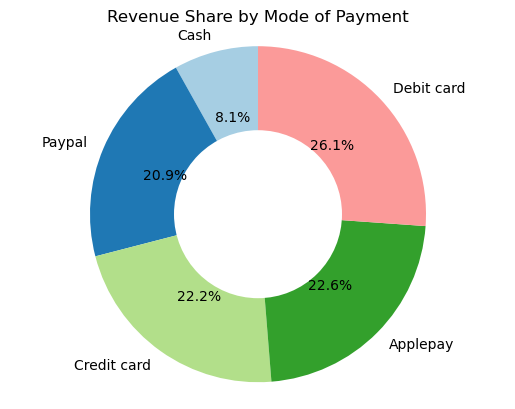

In [71]:
# Visualize the data with a donut chart
labels = result1['Mode_Of_Payment']
sizes = result1['Revenue_Share(%)']
colors = plt.cm.Paired(range(len(labels)))

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Revenue Share by Mode of Payment')
plt.show()

   Customer_ID First_Name   Last_Name  Total_spend_$
0           39      Bette       Kutch         2815.0
1           45   Mercedes     Monahan         2342.0
2           21       Lois     Kuvalis         2293.0
3           64     Lillie     Hilpert         2120.0
4            5     Maudie       Wyman         2048.0
5           13   Winfield  Konopelski         2002.0
6           25     Judson    Reynolds         1960.0
7           35       Deja       Morar         1773.0
8            9      Brady    Schiller         1696.0
9            6     Lilian      Durgan         1646.0


<Figure size 1000x600 with 0 Axes>

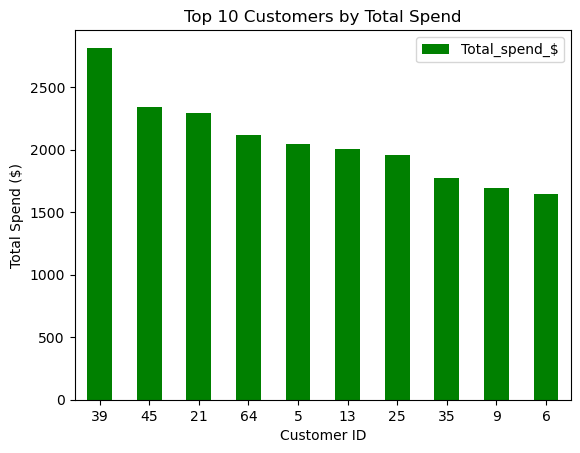

In [73]:
mycursor.execute("SELECT C.Customer_ID,C.First_Name,C.Last_Name,SUM(P.Amount) AS Total_spend_$ FROM orders O LEFT OUTER JOIN Payment P ON O.Order_ID = P.Order_ID LEFT OUTER JOIN customer C ON O.Customer_ID = C.Customer_ID GROUP BY C.Customer_ID,C.First_Name,C.Last_Name ORDER BY Total_spend_$ DESC LIMIT 10;")

# Fetch the results
result1_5 = mycursor.fetchall()

# Convert results to a DataFrame
result1_5 = pd.DataFrame(result1_5, columns=["Customer_ID", "First_Name", "Last_Name", "Total_spend_$"])

# Print the results
print(result1_5)

# Visualization: Bar Chart for Total Spend
plt.figure(figsize=(10, 6))
result1_5.plot(x="Customer_ID", y="Total_spend_$", kind="bar", color='green', rot=0)
plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Customer ID")
plt.ylabel("Total Spend ($)")
plt.show()

   Customer_ID First_Name   Last_Name  LTR($)  AOV($)  No_of_orders
0           39      Bette       Kutch  2815.0  938.33             3
1           45   Mercedes     Monahan  2342.0  780.67             3
2           21       Lois     Kuvalis  2293.0  764.33             3
3           64     Lillie     Hilpert  2120.0  706.67             3
4            5     Maudie       Wyman  2048.0  682.67             3
5           13   Winfield  Konopelski  2002.0  500.50             4
6           25     Judson    Reynolds  1960.0  653.33             3
7           35       Deja       Morar  1773.0  886.50             2
8            9      Brady    Schiller  1696.0  848.00             2
9            6     Lilian      Durgan  1646.0  548.67             3


<Figure size 1000x600 with 0 Axes>

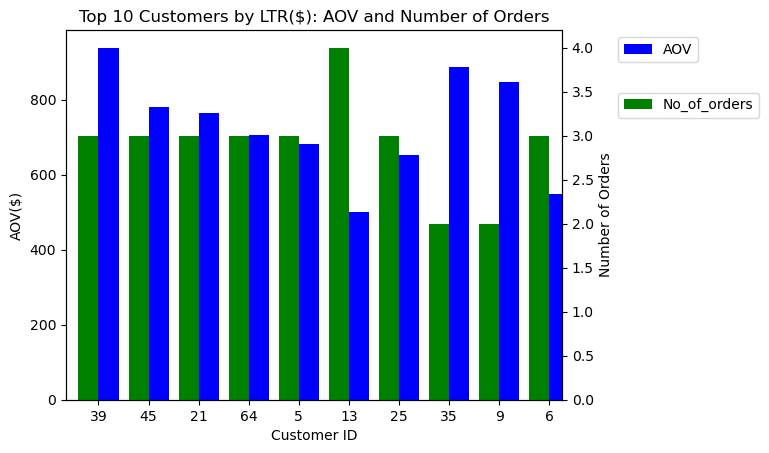

In [65]:
# Execute the query
mycursor.execute("SELECT Customer_ID, First_Name, Last_Name, Total_rev AS 'LTR($)', ROUND(AOV, 2) AS 'AOV($)', No_of_orders FROM (SELECT C.Customer_ID, C.First_Name, C.Last_Name, AVG(P.amount) AS AOV, COUNT(p.amount) AS No_of_orders, SUM(P.amount) AS Total_rev,RANK() OVER (ORDER BY SUM(P.amount) DESC, AVG(P.amount) DESC) AS Cust_Rank FROM Customer C LEFT OUTER JOIN Orders O ON C.Customer_ID = O.Customer_ID LEFT OUTER JOIN Payment P ON O.Order_ID = P.Order_ID GROUP BY C.Customer_ID, C.First_Name, C.Last_Name) RankedCustomers WHERE Cust_Rank <= 10;")

# Convert results to a DataFrame
result2 = pd.DataFrame(mycursor.fetchall(), columns=["Customer_ID", "First_Name", "Last_Name", "LTR($)", "AOV($)", "No_of_orders"])

# Close cursor and connection
#mycursor.close()
#conn.close()

# Print the results
print(result2)

# Visualization: Bar Chart
plt.figure(figsize=(10, 6))
ax1 = result2.plot(x="Customer_ID", y="AOV($)", kind="bar", color='blue', rot=0, position=0, width=0.4)
ax2 = result2.plot(x="Customer_ID", y="No_of_orders", kind="bar", color='green', rot=0, position=1, width=0.4, secondary_y=True, ax=ax1)

ax1.set_title("Top 10 Customers by LTR($): AOV and Number of Orders")
ax1.set_xlabel("Customer ID")
ax1.set_ylabel("AOV($)")
ax2.set_ylabel("Number of Orders")
# Place the legend outside the chart area
ax1.legend(["AOV"], loc="upper left", bbox_to_anchor=(1.1, 1))
ax2.legend(["No_of_orders"], loc="upper left", bbox_to_anchor=(1.1, 0.85))    
    
plt.show()
